# Imports, versões e reprodutibilidade

In [ ]:
!pip install optuna -q
!pip install tensorflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 843.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 63.8 MB/s eta 0:00:00


In [ ]:
!python --version
!pip show tensorflow

Python 3.12.13
Name: tensorflow
Version: 2.21.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: absl-py, astunparse, flatbuffers, gast, google_pasta, grpcio, h5py, keras, libclang, ml_dtypes, numpy, opt_einsum, packaging, protobuf, requests, setuptools, six, termcolor, typing_extensions, wrapt
Required-by: 


In [ ]:
import os
import pathlib
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt

import tensorflow as tf
import keras

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import optuna

# Exibe as versões das bibliotecas para garantir compatibilidade
print(f"Versões usadas:\n"
      f"TensorFlow: {tf.__version__}\n"
      f"Keras: {keras.__version__}\n"
      f"NumPy: {np.__version__}\n"
      f"Pandas: {pd.__version__}\n"
      f"Matplotlib: {matplotlib.__version__}\n")
print(f"Versão do Optuna: {optuna.__version__}")
# --- Configuração de reprodutibilidade ---
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


Versões usadas:
TensorFlow: 2.21.0
Keras: 3.13.2
NumPy: 2.0.2
Pandas: 2.2.2
Matplotlib: 3.10.0

Versão do Optuna: 4.8.0


# Download do dataset

In [ ]:
# --- Download do dataset TensorFlow Flowers ---
# O dataset será baixado automaticamente e carregado a partir da estrutura de pastas original.

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = tf.keras.utils.get_file(
    fname="flower_photos",
    origin=dataset_url,
    untar=True
)

data_dir = pathlib.Path(data_dir)

# Em alguns ambientes, o arquivo é extraído dentro de uma subpasta também chamada flower_photos.
# Esta verificação evita erro de caminho.
if (data_dir / "flower_photos").exists():
    data_dir = data_dir / "flower_photos"

print("📁 Caminho final do dataset:")
print(data_dir)

class_names = sorted([item.name for item in data_dir.iterdir() if item.is_dir()])

print("\n🌼 Classes encontradas:")
print(class_names)

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
📁 Caminho final do dataset:
/root/.keras/datasets/flower_photos/flower_photos

🌼 Classes encontradas:
['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


## Construção do dataframe de imagens

In [ ]:
# --- Construção de um dataframe com caminhos das imagens e classes ---

image_paths = []
labels = []

for class_name in class_names:
    class_dir = data_dir / class_name

    for image_path in class_dir.glob("*"):
        image_paths.append(str(image_path))
        labels.append(class_name)

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

# Cria um mapeamento entre o nome da classe e um código numérico
label_to_id = {class_name: idx for idx, class_name in enumerate(class_names)}
id_to_label = {idx: class_name for class_name, idx in label_to_id.items()}

df["label_id"] = df["label"].map(label_to_id).astype("int32")

print("Total de imagens:", len(df))
print("\n Mapeamento das classes:")
print(label_to_id)

print("\n Amostra do dataframe:")
display(df.head())

print("\n Distribuição das classes:")
display(df["label"].value_counts())

Total de imagens: 3670

 Mapeamento das classes:
{'daisy': 0, 'dandelion': 1, 'roses': 2, 'sunflowers': 3, 'tulips': 4}

 Amostra do dataframe:


,image_path,label,label_id
0,/root/.keras/datasets/flower_photos/flower_pho...,daisy,0
1,/root/.keras/datasets/flower_photos/flower_pho...,daisy,0
2,/root/.keras/datasets/flower_photos/flower_pho...,daisy,0
3,/root/.keras/datasets/flower_photos/flower_pho...,daisy,0
4,/root/.keras/datasets/flower_photos/flower_pho...,daisy,0



 Distribuição das classes:


,count
label,
dandelion,898
tulips,799
sunflowers,699
roses,641
daisy,633


## Visualização de amostras

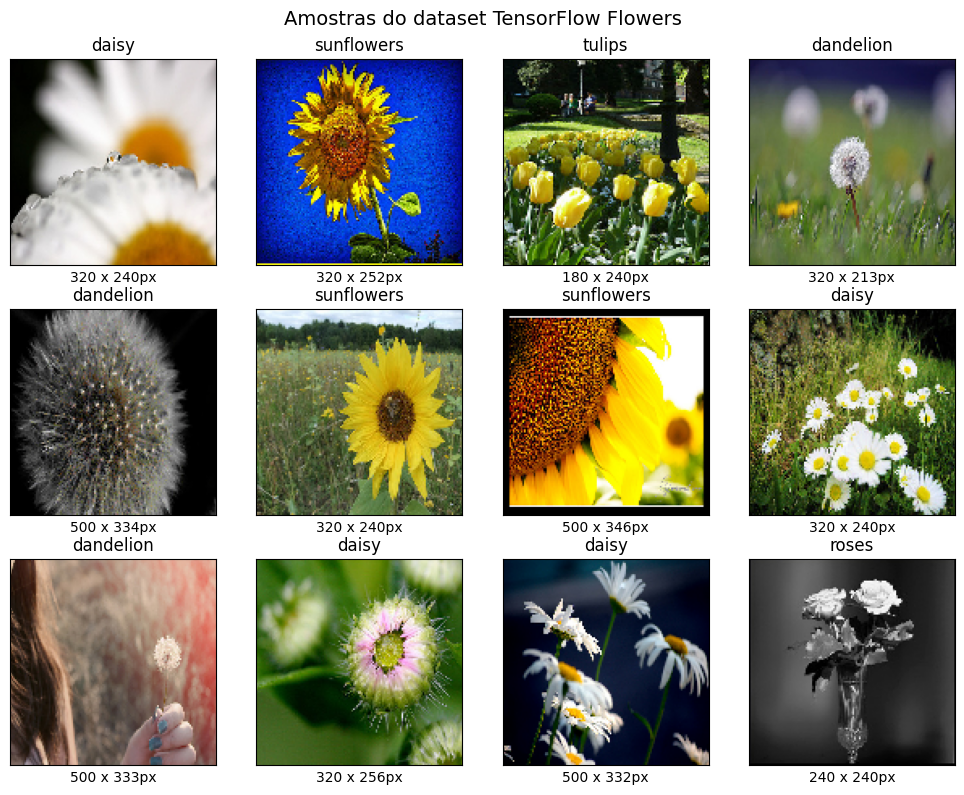

In [ ]:
# --- Visualização de algumas imagens do dataset ---

plt.figure(figsize=(10, 8))

sample_df = df.sample(12, random_state=SEED).reset_index(drop=True)

for i, row in sample_df.iterrows():
    # Carrega a imagem no tamanho original apenas para verificar suas dimensões
    img_original = tf.keras.utils.load_img(row["image_path"])
    largura, altura = img_original.size

    # Carrega a imagem redimensionada apenas para visualização padronizada na grade
    img = tf.keras.utils.load_img(row["image_path"], target_size=(128, 128))

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(row["label"])
    plt.xlabel(f"{largura} x {altura}px")
    plt.xticks([])
    plt.yticks([])

plt.suptitle("Amostras do dataset TensorFlow Flowers", fontsize=14)
plt.tight_layout()
plt.show()

## Divisão do dataset

In [ ]:
# --- Divisão holdout: treino, validação e teste ---
# O conjunto de teste será separado desde o início e usado apenas na avaliação final.

# Primeiro, separamos 15% dos dados para teste.
df_temp, df_teste = train_test_split(
    df,
    test_size=0.15,
    stratify=df["label_id"],
    random_state=SEED
)

# Depois, separamos parte do restante para validação.
# Como o df_temp contém 85% dos dados, usar test_size=0.1765 gera aproximadamente 15% do total original para validação.
df_treino, df_validacao = train_test_split(
    df_temp,
    test_size=0.1765,
    stratify=df_temp["label_id"],
    random_state=SEED
)

print("Quantidade de imagens em cada conjunto:")
print(f"Treino: {len(df_treino)} imagens")
print(f"Validação: {len(df_validacao)} imagens")
print(f"Teste: {len(df_teste)} imagens")

print("\n Percentuais aproximados:")
print(f"Treino: {len(df_treino) / len(df) * 100:.1f}%")
print(f"Validação: {len(df_validacao) / len(df) * 100:.1f}%")
print(f"Teste: {len(df_teste) / len(df) * 100:.1f}%")
# --- Conferência da distribuição das classes em cada conjunto ---

dist_treino = df_treino["label"].value_counts(normalize=True).sort_index()
dist_validacao = df_validacao["label"].value_counts(normalize=True).sort_index()
dist_teste = df_teste["label"].value_counts(normalize=True).sort_index()

df_distribuicao = pd.DataFrame({
    "Treino (%)": dist_treino * 100,
    "Validação (%)": dist_validacao * 100,
    "Teste (%)": dist_teste * 100
})

display(df_distribuicao.round(2))

Quantidade de imagens em cada conjunto:
Treino: 2568 imagens
Validação: 551 imagens
Teste: 551 imagens

 Percentuais aproximados:
Treino: 70.0%
Validação: 15.0%
Teste: 15.0%


,Treino (%),Validação (%),Teste (%)
label,,,
daisy,17.25,17.24,17.24
dandelion,24.45,24.50,24.50
roses,17.48,17.42,17.42
sunflowers,19.04,19.06,19.06
tulips,21.77,21.78,21.78


## Amostra para o tuning

In [ ]:
# --- Criação de uma amostra estratificada para o tuning ---
# Esta etapa simula o que deve ser feito quando o dataset escolhido for grande demais.
# O tuning será feito em uma amostra menor, preservando a proporção das classes.

TAMANHO_AMOSTRA_TREINO = 1500
TAMANHO_AMOSTRA_VALIDACAO = 500

# Se o conjunto for menor que o tamanho definido, usa o conjunto inteiro.
n_treino = min(TAMANHO_AMOSTRA_TREINO, len(df_treino))
n_validacao = min(TAMANHO_AMOSTRA_VALIDACAO, len(df_validacao))

df_treino_tuning, _ = train_test_split(
    df_treino,
    train_size=n_treino,
    stratify=df_treino["label_id"],
    random_state=SEED
)

df_validacao_tuning, _ = train_test_split(
    df_validacao,
    train_size=n_validacao,
    stratify=df_validacao["label_id"],
    random_state=SEED
)

print(" Amostra usada no tuning:")
print(f"Treino tuning: {len(df_treino_tuning)} imagens")
print(f"Validação tuning: {len(df_validacao_tuning)} imagens")

# --- Conferência da distribuição das classes na amostra de tuning ---

df_dist_tuning = pd.DataFrame({
    "Treino tuning (%)": df_treino_tuning["label"].value_counts(normalize=True).sort_index() * 100,
    "Validação tuning (%)": df_validacao_tuning["label"].value_counts(normalize=True).sort_index() * 100
})

display(df_dist_tuning.round(2))

 Amostra usada no tuning:
Treino tuning: 1500 imagens
Validação tuning: 500 imagens


,Treino tuning (%),Validação tuning (%)
label,,
daisy,17.27,17.2
dandelion,24.47,24.6
roses,17.47,17.4
sunflowers,19.07,19.0
tulips,21.73,21.8


# Criar dataset

In [ ]:
# --- Parâmetros principais ---

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

num_classes = len(class_names)

print(f" Tamanho das imagens: {IMG_SIZE}")
print(f" Batch size: {BATCH_SIZE}")
print(f" Número de classes: {num_classes}")

# --- Função para carregar e preparar cada imagem ---

def carregar_imagem(image_path, label):
    # Lê o arquivo da imagem
    img = tf.io.read_file(image_path)

    # Decodifica a imagem em 3 canais (RGB)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)

    # Redimensiona para o tamanho definido
    img = tf.image.resize(img, IMG_SIZE)

    # Normaliza os pixels para o intervalo [0, 1]
    img = tf.cast(img, tf.float32) / 255.0

    return img, label

    # --- Função para criar um tf.data.Dataset a partir de um dataframe ---

def criar_dataset(dataframe, shuffle=False):
    image_paths = dataframe["image_path"].values
    labels = dataframe["label_id"].values.astype("int32")

    ds = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)

    ds = ds.map(carregar_imagem, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds

    # --- Datasets usados no tuning com Optuna ---

ds_treino_tuning = criar_dataset(df_treino_tuning, shuffle=True)
ds_validacao_tuning = criar_dataset(df_validacao_tuning, shuffle=False)

print("✅ Datasets de tuning criados.")
print(ds_treino_tuning)
print(ds_validacao_tuning)

# --- Verificando um batch do dataset de treino ---

for imagens_batch, labels_batch in ds_treino_tuning.take(1):
    print("Formato do batch de imagens:", imagens_batch.shape)
    print("Formato do batch de rótulos:", labels_batch.shape)
    print("Tipo das imagens:", imagens_batch.dtype)
    print("Tipo dos rótulos:", labels_batch.dtype)
    print("Valor mínimo dos pixels:", tf.reduce_min(imagens_batch).numpy())
    print("Valor máximo dos pixels:", tf.reduce_max(imagens_batch).numpy())

 Tamanho das imagens: (128, 128)
 Batch size: 32
 Número de classes: 5
✅ Datasets de tuning criados.
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
Formato do batch de imagens: (32, 128, 128, 3)
Formato do batch de rótulos: (32,)
Tipo das imagens: <dtype: 'float32'>
Tipo dos rótulos: <dtype: 'int32'>
Valor mínimo dos pixels: 0.0
Valor máximo dos pixels: 1.0


## Visualizando imagens tratadas

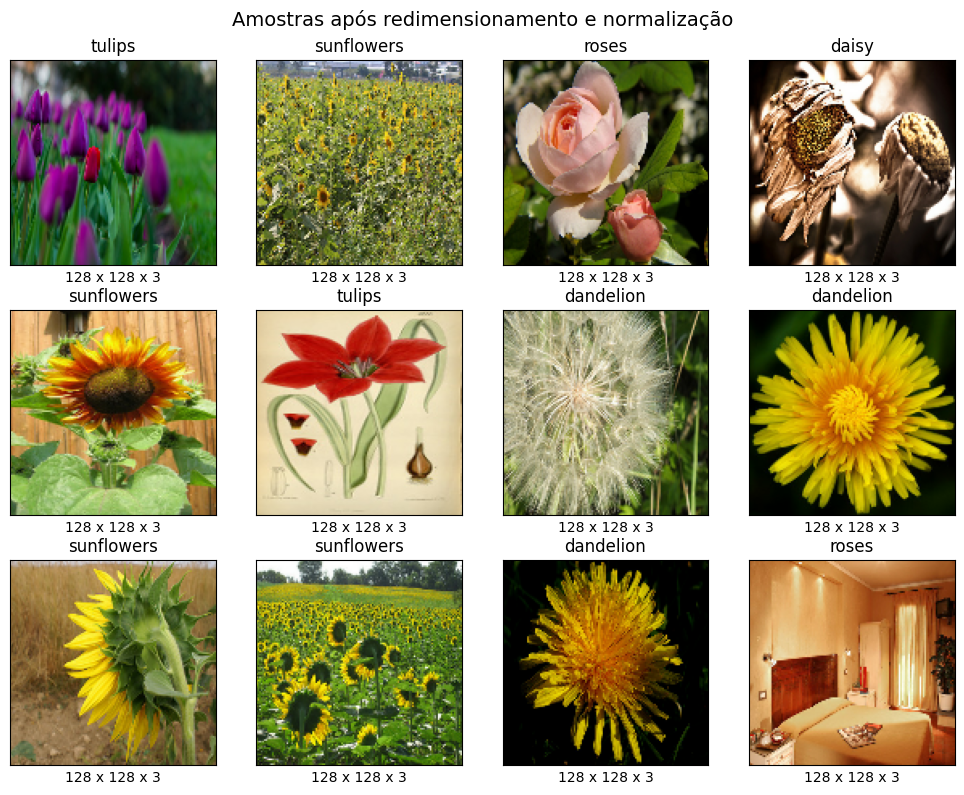

In [ ]:
# --- Visualizando imagens após o pipeline de carregamento ---

plt.figure(figsize=(10, 8))

for imagens_batch, labels_batch in ds_treino_tuning.take(1):
    for i in range(12):
        altura = imagens_batch[i].shape[0]
        largura = imagens_batch[i].shape[1]
        canais = imagens_batch[i].shape[2]

        plt.subplot(3, 4, i + 1)
        plt.imshow(imagens_batch[i])
        plt.title(class_names[int(labels_batch[i])])
        plt.xlabel(f"{largura} x {altura} x {canais}")
        plt.xticks([])
        plt.yticks([])

plt.suptitle("Amostras após redimensionamento e normalização", fontsize=14)
plt.tight_layout()
plt.show()

# CNN baseline

In [ ]:
# --- Função para criar uma CNN baseline ---

def criar_cnn_baseline():
    model = keras.Sequential([
        keras.layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

        keras.layers.Conv2D(32, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Conv2D(64, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Flatten(),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

    # --- Criando e visualizando a arquitetura baseline ---

modelo_baseline = criar_cnn_baseline()
modelo_baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,965 (28.20 MB)

 Trainable params: 7,392,965 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

## Treinamento da CCN baseline

In [ ]:
# --- Early stopping para evitar treinamento desnecessário ---

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# --- Treinamento da CNN baseline na amostra de tuning ---

EPOCHS_BASELINE = 15

history_baseline = modelo_baseline.fit(
    ds_treino_tuning,
    validation_data=ds_validacao_tuning,
    epochs=EPOCHS_BASELINE,
    callbacks=[early_stopping],
    verbose=1
)

# --- Função para plotar curvas de treino e validação ---

def plotar_curvas_treinamento(history, titulo="Curvas de treinamento"):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Treino")
    plt.plot(epochs_range, val_acc, label="Validação")
    plt.title("Acurácia")
    plt.xlabel("Época")
    plt.ylabel("Acurácia")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Treino")
    plt.plot(epochs_range, val_loss, label="Validação")
    plt.title("Loss")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()

    plt.suptitle(titulo, fontsize=14)
    plt.tight_layout()
    plt.show()

Epoch 1/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 17s 341ms/step - accuracy: 0.4240 - loss: 1.3578 - val_accuracy: 0.5960 - val_loss: 1.0584
Epoch 2/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 332ms/step - accuracy: 0.6060 - loss: 1.0345 - val_accuracy: 0.6360 - val_loss: 0.9946
Epoch 3/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 341ms/step - accuracy: 0.7107 - loss: 0.7758 - val_accuracy: 0.6400 - val_loss: 0.9642
Epoch 4/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 333ms/step - accuracy: 0.8120 - loss: 0.5500 - val_accuracy: 0.6240 - val_loss: 0.9478
Epoch 5/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 337ms/step - accuracy: 0.8887 - loss: 0.3274 - val_accuracy: 0.6180 - val_loss: 1.0134
Epoch 6/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 332ms/step - accuracy: 0.9400 - loss: 0.2005 - val_accuracy: 0.6480 - val_loss: 1.0692
Epoch 7/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 335ms/step - accuracy: 0.9680 - loss: 0.1254 - val_accuracy: 0.6220 - val_loss: 1.1666


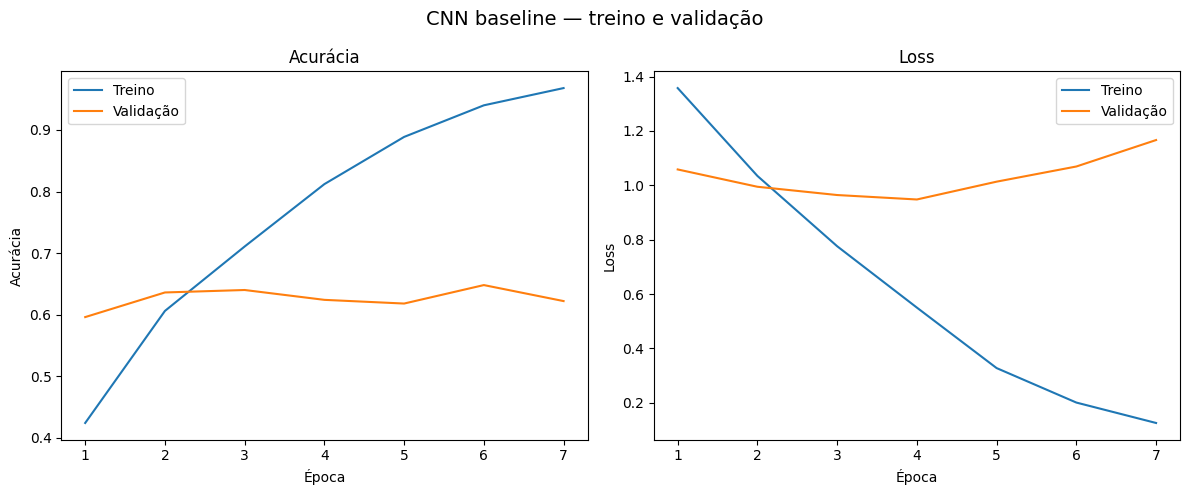

In [ ]:
plotar_curvas_treinamento(history_baseline, "CNN baseline — treino e validação")

In [ ]:
# --- Melhor desempenho da baseline na validação ---

melhor_val_acc_baseline = max(history_baseline.history["val_accuracy"])
melhor_val_loss_baseline = min(history_baseline.history["val_loss"])

print(f"📌 Melhor acurácia de validação da baseline: {melhor_val_acc_baseline:.4f}")
print(f"📌 Menor loss de validação da baseline: {melhor_val_loss_baseline:.4f}")

📌 Melhor acurácia de validação da baseline: 0.6480
📌 Menor loss de validação da baseline: 0.9478


# CNN para tuning

In [ ]:
# --- Função para criar uma CNN com hiperparâmetros definidos pelo Optuna ---

def criar_cnn_optuna(trial):
    num_filtros_1 = trial.suggest_int("num_filtros_1", 16, 64, step=16)
    num_filtros_2 = trial.suggest_int("num_filtros_2", 32, 128, step=32)
    dense_units = trial.suggest_int("dense_units", 64, 256, step=64)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5, step=0.1)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)

    model = keras.Sequential([
        keras.layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

        keras.layers.Conv2D(num_filtros_1, (3, 3), activation="relu"),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Conv2D(num_filtros_2, (3, 3), activation="relu"),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Flatten(),
        keras.layers.Dense(dense_units, activation="relu"),
        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# Configuração das trials (função objetivo)

In [ ]:
# --- Função objetivo ---
# Cada trial corresponde a uma configuração diferente de hiperparâmetros.

def objective(trial):
    model = criar_cnn_optuna(trial)

    early_stopping_trial = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        ds_treino_tuning,
        validation_data=ds_validacao_tuning,
        epochs=10,
        callbacks=[early_stopping_trial],
        verbose=0
    )

    melhor_val_accuracy = max(history.history["val_accuracy"])

    return melhor_val_accuracy

In [ ]:
# --- Execução do Optuna com TPE ---
# Orçamento fixo: número máximo de trials.

N_TRIALS = 15

sampler = optuna.samplers.TPESampler(seed=SEED)

study = optuna.create_study(
    direction="maximize",
    sampler=sampler
)

study.optimize(objective, n_trials=N_TRIALS)

[I 2026-05-19 02:50:15,048] A new study created in memory with name: no-name-87f4fad4-b1fe-4fe8-b37d-04773c37b2ad
[I 2026-05-19 02:53:17,253] Trial 0 finished with value: 0.3019999861717224 and parameters: {'num_filtros_1': 32, 'num_filtros_2': 128, 'dense_units': 192, 'dropout_rate': 0.30000000000000004, 'learning_rate': 0.0002051338263087451}. Best is trial 0 with value: 0.3019999861717224.
[I 2026-05-19 02:54:15,413] Trial 1 finished with value: 0.27000001072883606 and parameters: {'num_filtros_1': 16, 'num_filtros_2': 32, 'dense_units': 256, 'dropout_rate': 0.4, 'learning_rate': 0.0026070247583707684}. Best is trial 0 with value: 0.3019999861717224.
[I 2026-05-19 02:56:46,426] Trial 2 finished with value: 0.3779999911785126 and parameters: {'num_filtros_1': 16, 'num_filtros_2': 128, 'dense_units': 256, 'dropout_rate': 0.2, 'learning_rate': 0.0002310201887845295}. Best is trial 2 with value: 0.3779999911785126.
[I 2026-05-19 02:58:05,822] Trial 3 finished with value: 0.25 and parame

In [ ]:
# --- Melhor configuração encontrada pelo Optuna ---

print(" Melhor trial:")
print(f"Número do trial: {study.best_trial.number}")
print(f"Acurácia de validação: {study.best_value:.4f}")

print("\n Hiperparâmetros encontrados:")
for param, value in study.best_params.items():
    print(f"{param}: {value}")

 Melhor trial:
Número do trial: 2
Acurácia de validação: 0.3780

 Hiperparâmetros encontrados:
num_filtros_1: 16
num_filtros_2: 128
dense_units: 256
dropout_rate: 0.2
learning_rate: 0.0002310201887845295


In [ ]:
# --- Tabela comparativa dos trials do Optuna ---

df_trials = study.trials_dataframe()

# Seleciona apenas as colunas mais relevantes para análise
colunas_interesse = [
    "number",
    "value",
    "params_num_filtros_1",
    "params_num_filtros_2",
    "params_dense_units",
    "params_dropout_rate",
    "params_learning_rate",
    "state"
]

df_trials_resumo = df_trials[colunas_interesse].copy()

# Renomeia colunas para facilitar leitura
df_trials_resumo = df_trials_resumo.rename(columns={
    "number": "trial",
    "value": "val_accuracy",
    "params_num_filtros_1": "filtros_1",
    "params_num_filtros_2": "filtros_2",
    "params_dense_units": "dense_units",
    "params_dropout_rate": "dropout",
    "params_learning_rate": "learning_rate",
    "state": "status"
})

# Ordena pelo melhor desempenho
df_trials_resumo = df_trials_resumo.sort_values(
    by="val_accuracy",
    ascending=False
).reset_index(drop=True)

display(df_trials_resumo)

,trial,val_accuracy,filtros_1,filtros_2,dense_units,dropout,learning_rate,status
0,2,0.378,16,128,256,0.2,0.000231,COMPLETE
1,8,0.318,16,64,64,0.5,0.000329,COMPLETE
2,11,0.312,16,96,128,0.1,0.000396,COMPLETE
3,0,0.302,32,128,192,0.3,0.000205,COMPLETE
4,9,0.300,48,64,192,0.3,0.000234,COMPLETE
5,14,0.298,16,128,256,0.2,0.001559,COMPLETE
6,6,0.294,48,32,64,0.5,0.008536,COMPLETE
7,4,0.288,48,32,128,0.2,0.000817,COMPLETE
8,12,0.286,32,96,64,0.5,0.000122,COMPLETE
9,10,0.278,32,128,256,0.1,0.002012,COMPLETE


,Modelo,Acurácia de validação
0,CNN baseline,0.648
1,CNN otimizada com Optuna,0.378


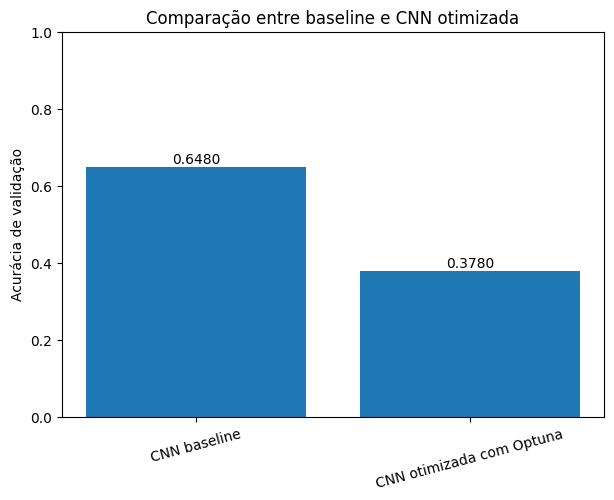

In [ ]:
# --- Comparação entre baseline e melhor modelo encontrado pelo Optuna ---

df_comparacao_validacao = pd.DataFrame({
    "Modelo": ["CNN baseline", "CNN otimizada com Optuna"],
    "Acurácia de validação": [melhor_val_acc_baseline, study.best_value]
})

display(df_comparacao_validacao)

# --- Gráfico comparativo: baseline vs Optuna ---

plt.figure(figsize=(7, 5))
plt.bar(
    df_comparacao_validacao["Modelo"],
    df_comparacao_validacao["Acurácia de validação"]
)

plt.ylim(0, 1)
plt.ylabel("Acurácia de validação")
plt.title("Comparação entre baseline e CNN otimizada")

for i, valor in enumerate(df_comparacao_validacao["Acurácia de validação"]):
    plt.text(i, valor + 0.01, f"{valor:.4f}", ha="center")

plt.xticks(rotation=15)
plt.show()

In [ ]:
# --- Gráfico de histórico da otimização ---
# Mostra como a melhor acurácia de validação evoluiu ao longo dos trials.

optuna.visualization.plot_optimization_history(study)

In [ ]:
# --- Gráfico de importância dos hiperparâmetros ---
# Atenção: com poucos trials, este gráfico é apenas indicativo.

optuna.visualization.plot_param_importances(study)

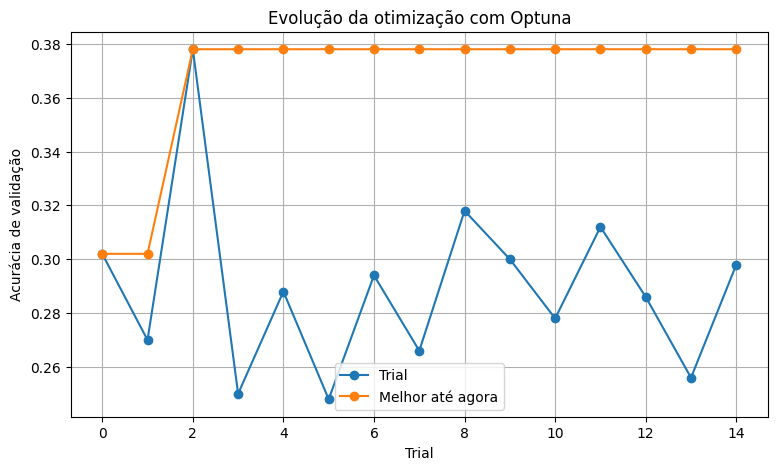

In [ ]:
# --- Alternativa em Matplotlib: evolução dos trials ---

df_trials_plot = df_trials_resumo.sort_values("trial").copy()
df_trials_plot["melhor_ate_agora"] = df_trials_plot["val_accuracy"].cummax()

plt.figure(figsize=(9, 5))
plt.plot(df_trials_plot["trial"], df_trials_plot["val_accuracy"], marker="o", label="Trial")
plt.plot(df_trials_plot["trial"], df_trials_plot["melhor_ate_agora"], marker="o", label="Melhor até agora")

plt.xlabel("Trial")
plt.ylabel("Acurácia de validação")
plt.title("Evolução da otimização com Optuna")
plt.legend()
plt.grid(True)
plt.show()

# Treinamento com o dataset completo

In [ ]:
# --- Criação do modelo vencedor com os melhores hiperparâmetros ---

best_params = study.best_params

def criar_cnn_com_params(params):
    model = keras.Sequential([
        keras.layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

        keras.layers.Conv2D(params["num_filtros_1"], (3, 3), activation="relu"),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Conv2D(params["num_filtros_2"], (3, 3), activation="relu"),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Flatten(),
        keras.layers.Dense(params["dense_units"], activation="relu"),
        keras.layers.Dropout(params["dropout_rate"]),
        keras.layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=params["learning_rate"]),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

modelo_vencedor = criar_cnn_com_params(best_params)
modelo_vencedor.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_32 (Conv2D)              │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 126, 126, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 61, 61, 128)    │        18,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 61, 61, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 256)            │    29,491,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,512,325 (112.58 MB)

 Trainable params: 29,512,037 (112.58 MB)

 Non-trainable params: 288 (1.12 KB)

In [ ]:
# --- Datasets completos para treino final e avaliação ---

ds_treino = criar_dataset(df_treino, shuffle=True)
ds_validacao = criar_dataset(df_validacao, shuffle=False)
ds_teste = criar_dataset(df_teste, shuffle=False)

print(" Datasets completos criados.")

 Datasets completos criados.


Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 65s 782ms/step - accuracy: 0.3773 - loss: 4.1617 - val_accuracy: 0.2722 - val_loss: 2.8862
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 63s 781ms/step - accuracy: 0.5744 - loss: 1.1599 - val_accuracy: 0.3321 - val_loss: 4.3106
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 64s 787ms/step - accuracy: 0.6998 - loss: 0.7825 - val_accuracy: 0.3648 - val_loss: 4.2261


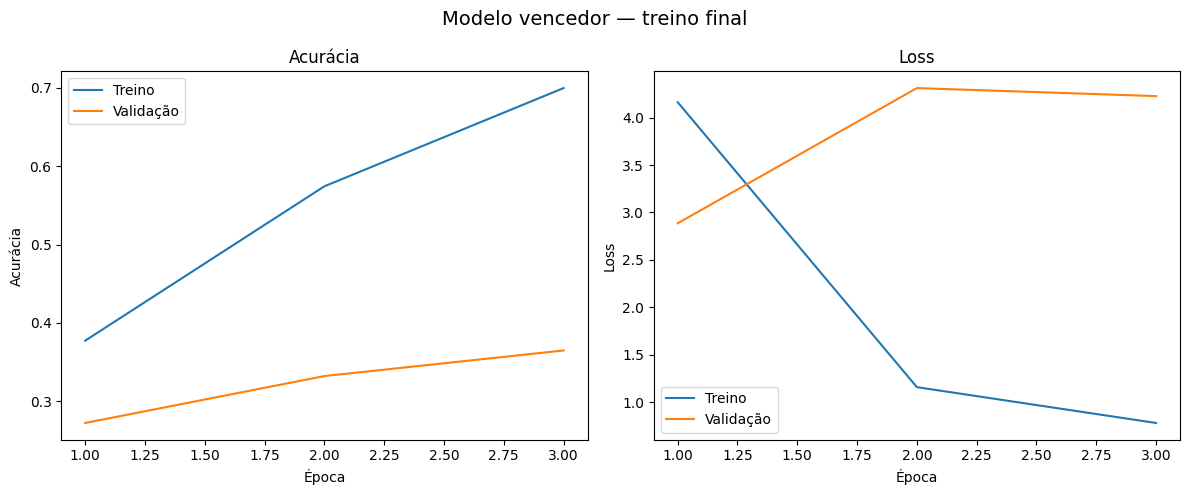

In [ ]:
# --- Treinamento final do modelo vencedor com o conjunto de treino completo ---

EPOCHS_FINAL = 20

history_vencedor = modelo_vencedor.fit(
    ds_treino,
    validation_data=ds_validacao,
    epochs=EPOCHS_FINAL,
    callbacks=[early_stopping],
    verbose=1
)

plotar_curvas_treinamento(history_vencedor, "Modelo vencedor — treino final")

In [ ]:
# --- Avaliação final no conjunto de teste ---

test_loss, test_acc = modelo_vencedor.evaluate(ds_teste, verbose=1)

print(f" Loss no teste: {test_loss:.4f}")
print(f" Acurácia no teste: {test_acc:.4f}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.2668 - loss: 2.8792
 Loss no teste: 2.8792
 Acurácia no teste: 0.2668


In [ ]:
# --- Tabela final de comparação ---

df_resultado_final = pd.DataFrame({
    "Modelo/Etapa": [
        "CNN baseline - validação tuning",
        "Melhor Optuna - validação tuning",
        "Modelo do teste final"
    ],
    "Acurácia": [
        melhor_val_acc_baseline,
        study.best_value,
        test_acc
    ]
})

display(df_resultado_final)

,Modelo/Etapa,Acurácia
0,CNN baseline - validação tuning,0.648000
1,Melhor Optuna - validação tuning,0.378000
2,Modelo do teste final,0.266788
